### Visualization

In [1]:
from helper_functions import *
import os
from datetime import datetime
# path = '/Users/sarce/Microscopic/l1_0.00_Dn1_0.00_T_0.15_2026-04-23_161129'

files = [f for f in os.listdir('.') if f.startswith('L')]

# def extract_datetime(filename):
#     # last two parts are date and time
#     parts = filename.rsplit('_', 2)
#     date_str = parts[-2]
#     time_str = parts[-1]
#     return datetime.strptime(f"{date_str}_{time_str}", "%Y-%m-%d_%H%M%S")

# most_recent = max(files, key=extract_datetime)

# # full path if you want it
# path = os.path.abspath(most_recent)

path = files[0]

# path = '/Users/sarce/Microscopic/l1_2.00_Dn1_0.10_T_10.00_2026-04-24_162358'
occupancies_t, tau_t, _, _, _ = load_sim(path)
path

'L_12.56_Dn1_1.00_lambda_10.00_2026-05-15_104324'

In [2]:
occupancies_t.shape, tau_t.shape

((22, 3, 1256), (22,))

In [3]:
1239/155, 150/12

(7.993548387096774, 12.5)

To plot, there are 4 parameters to specify:
- w (here 12) is the mesoscopic box size taken for the averaging. 
- start (here 0) and
end (here 1) are the start and end point of the time window you want to see. So if you want to only see the second half of time values you would make these 0.5 and 1.
- Nlines (here 5) is the number of lines you want to see (each for a different time).

In [4]:
files

['L_12.56_Dn1_1.00_lambda_10.00_2026-05-15_104324',
 'L_12.56_Dn1_1.00_lambda_10.00_2026-05-15_131930_new',
 'L_12.56_Dn1_1.00_lambda_100.00_2026-05-15_104516',
 'L_12.56_Dn1_1.00_lambda_10.00_2026-05-15_141341',
 'L_12.56_Dn1_1.00_lambda_10.00_2026-05-15_104633',
 'L_12.56_Dn1_1.00_lambda_10.00_2026-05-15_131930',
 'L_6.28_Dn1_1.00_lambda_1.00_2026-05-14_134934',
 'L_12.56_Dn1_1.00_lambda_10.00_2026-05-15_104354',
 'L_12.56_Dn1_1.00_lambda_10.00_2026-05-15_112809',
 'L_12.56_Dn1_1.00_lambda_10.00_2026-05-15_104443',
 'L_12.56_Dn1_1.00_lambda_10.00_2026-05-15_102116',
 'L_12.56_Dn1_1.00_lambda_10.00_2026-05-15_110508']

Seeing the cluster!

half_sites_L_18.85_Dn1_1.00_lambda_10.00_2026-05-18_151131
30


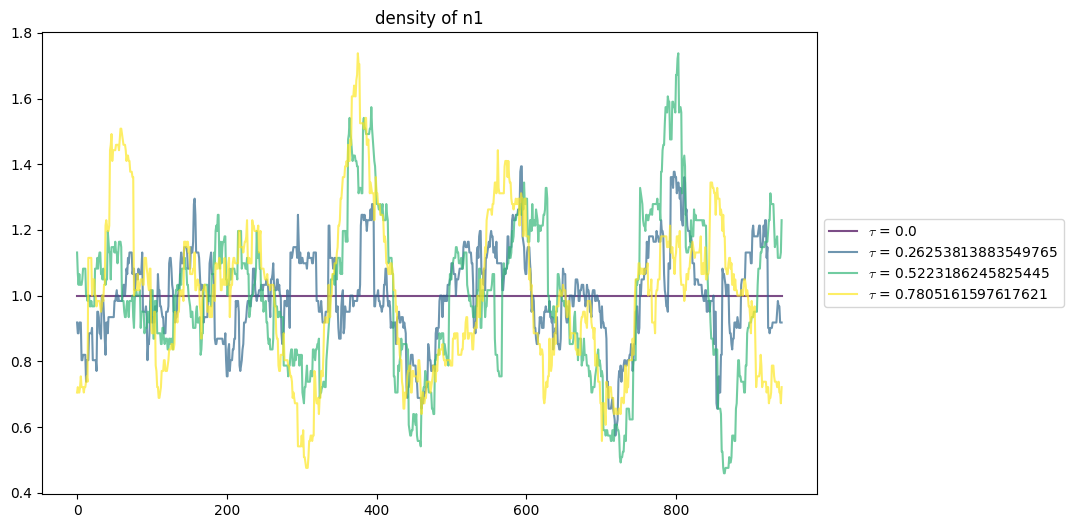

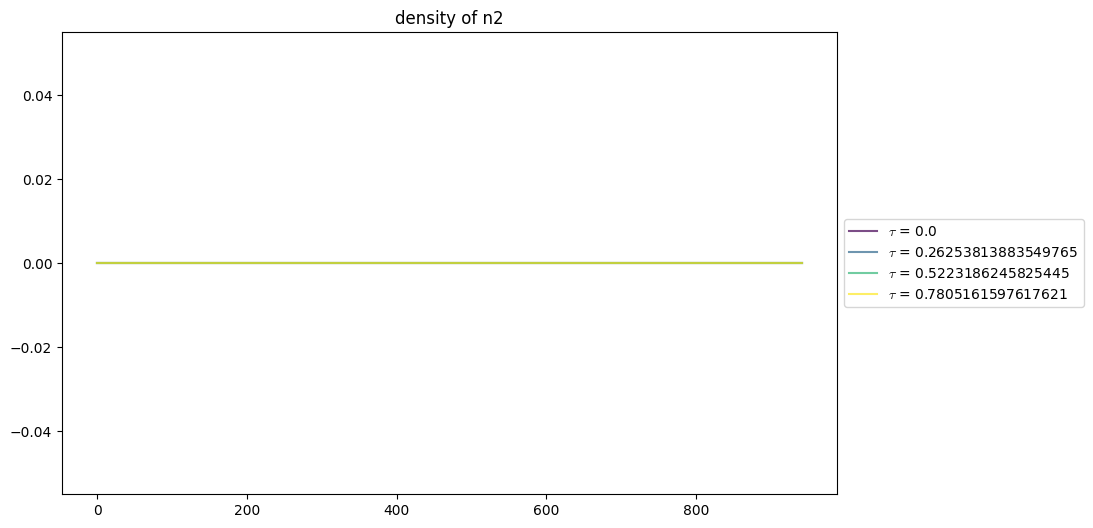

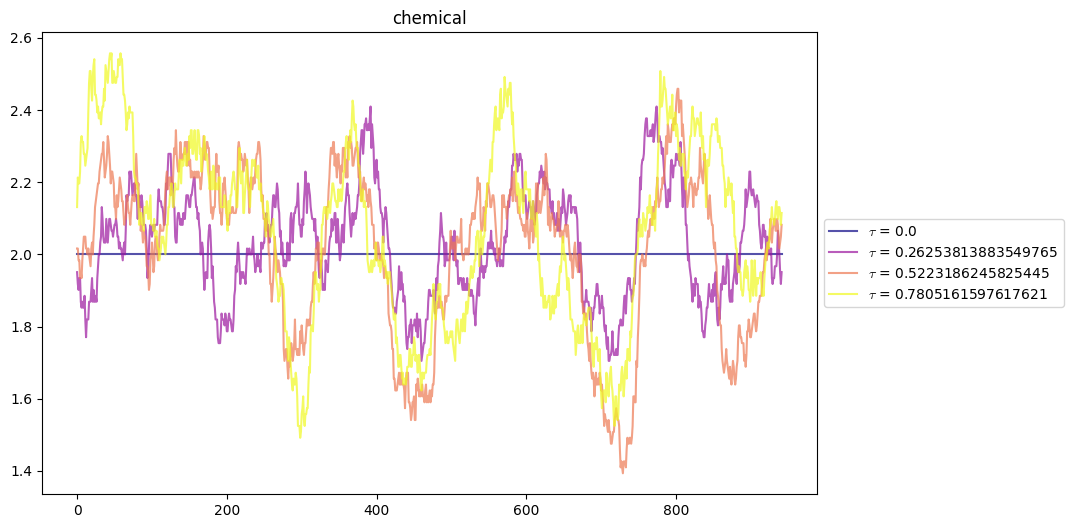

In [43]:
# path = files[8]
path = 'half_sites_L_18.85_Dn1_1.00_lambda_10.00_2026-05-18_151131'
print(path)
occupancies_t, tau_t, _, _, _ = load_sim(path)
w = int(occupancies_t.shape[2] ** 0.5)

print(w)
plot_results(occupancies_t, tau_t, w, 0, 0.2, 4)


half_sites_L_18.85_Dn1_1.00_lambda_10.00_2026-05-18_151928
61


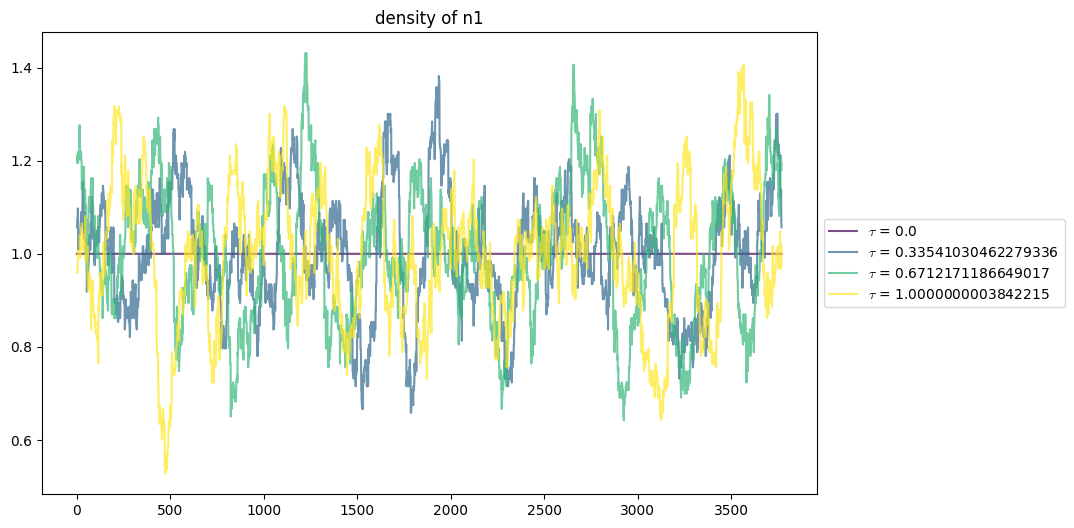

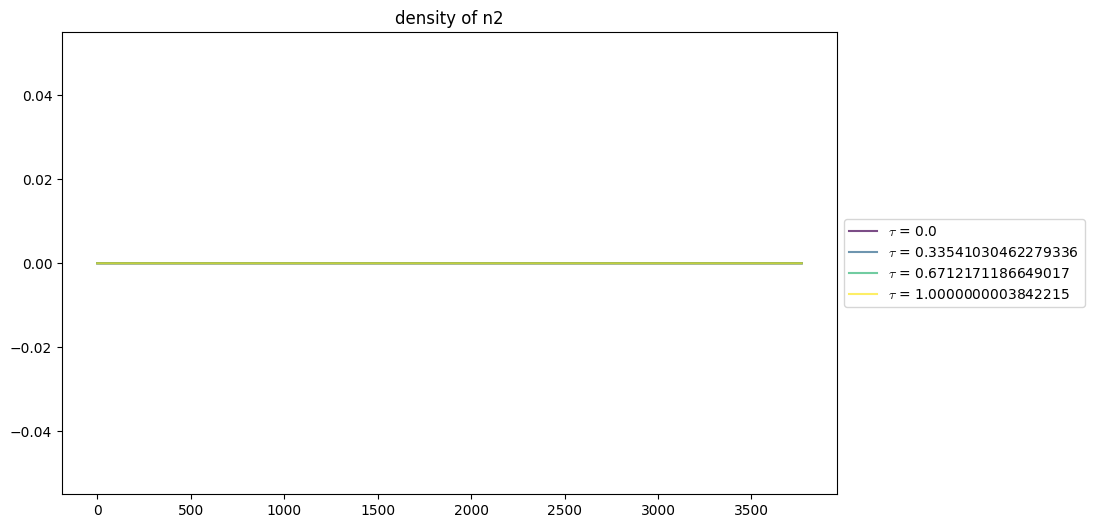

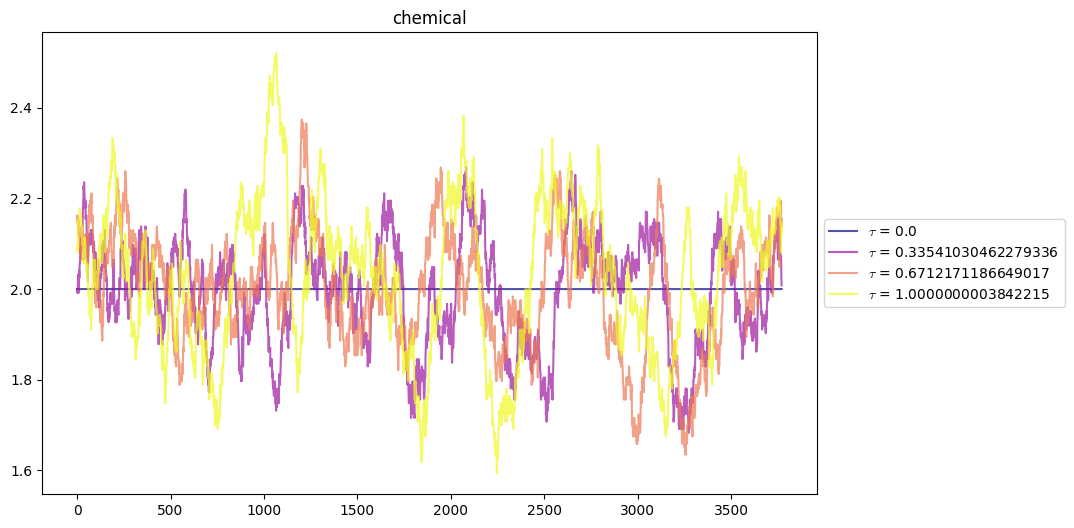

In [42]:
# path = files[8]
path = 'half_sites_L_18.85_Dn1_1.00_lambda_10.00_2026-05-18_151928'
print(path)
occupancies_t, tau_t, _, _, _ = load_sim(path)
w = int(occupancies_t.shape[2] ** 0.5)

print(w)
plot_results(occupancies_t, tau_t, w, 0, 1, 4)


In [6]:
occupancies_t.shape

(477, 3, 942)

getting the optimal window scaling

In [7]:
N = 150
maxima = np.zeros(N)

for i in range(N):
    maxima[i] = np.max(meso_avg(occupancies_t[-1,0,:], i))

Text(0.5, 1.0, 'Convergence of hydrodynamic limit (max peak height wrt average window size)')

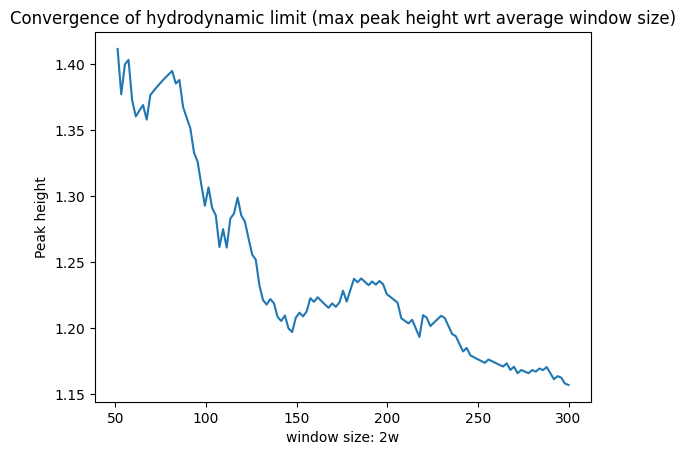

In [8]:
plt.plot(np.linspace(1, N * 2, N)[25:], maxima[25:])
plt.xlabel('window size: 2w')
plt.ylabel('Peak height')
plt.title('Convergence of hydrodynamic limit (max peak height wrt average window size)')

In [9]:
# i feel like 200 * 2 or so is reasonable. this is huge indeed. 
np.log(200) / np.log(occupancies_t.shape[2])

np.float64(0.7737022905368316)

In [10]:
np.mean(occupancies_t[-1, 0:]), np.var(occupancies_t[-1, 0,:])

(np.float64(1.004953998584572), np.float64(1.1804670912951167))

In [11]:
np.mean(occupancies_t[-1, 2,:]), np.var(occupancies_t[-1, 2,:])

(np.float64(2.0148619957537157), np.float64(2.101689949107694))

942

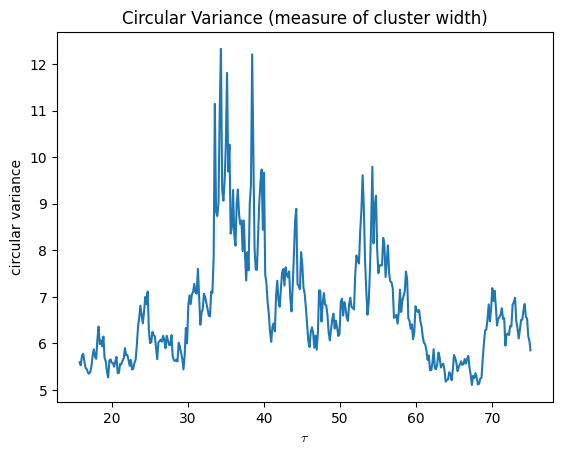

In [12]:
Nsites = occupancies_t.shape[2]

discrete_wave = np.array([np.exp((2 * np.pi / occupancies_t.shape[2]) * i * 1j) for i in range(occupancies_t.shape[2])])

product =  discrete_wave * occupancies_t[:, 0, :]
m1 = np.sum(product, axis=1) / np.sum(occupancies_t[:, 0, :], axis=1)
circle_variances = -2 * np.log(np.abs(m1))
plt.plot(tau_t[100:], circle_variances[100:])
plt.xlabel(fr'$\tau$')
plt.ylabel('circular variance')
plt.title('Circular Variance (measure of cluster width)')
Nsites

In [13]:
tau_t.shape

(477,)

In [14]:
product.shape

(477, 942)

In [15]:
np.mean(occupancies_t[-1, 0,:]), np.var(occupancies_t[-1, 0,:])

(np.float64(1.0), np.float64(1.1804670912951167))

Text(0.5, 1.0, 'Variance / mean of n1')

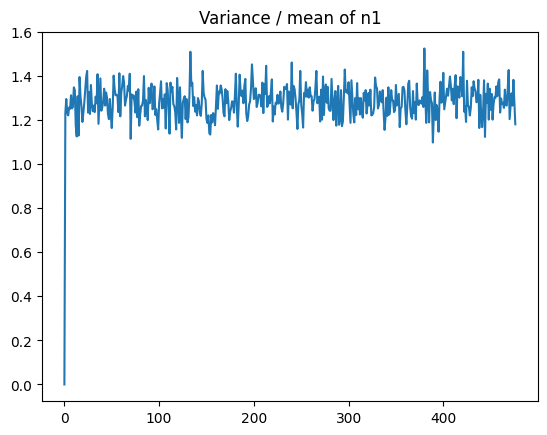

In [16]:
plt.plot([np.var(occupancies_t[i, 0,:]) for i in range(occupancies_t.shape[0] )])
plt.title('Variance / mean of n1')

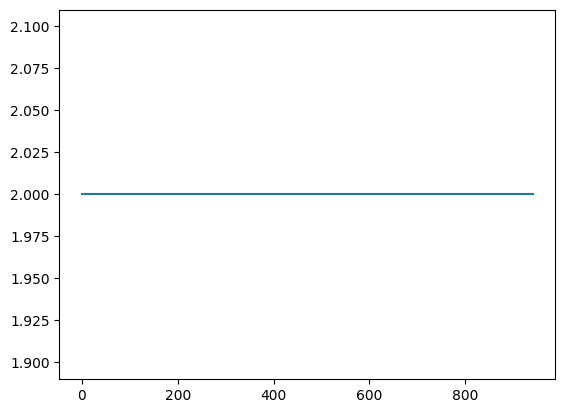

In [17]:
meso = np.zeros(occupancies_t.shape, dtype=float)

for i, _ in enumerate(occupancies_t):
    meso[i,2,:] = meso_avg(occupancies_t[i,2,:], w)

plt.plot(meso[0, 2,:])

In [18]:
meso.shape

(477, 3, 942)

In [19]:
import numpy as np

# choose 10 indices (example: random)
indices = np.random.choice(len(tau_t), size=49, replace=False)

c = np.mean(meso[0, 2, :])
a = meso[0, 2, 0] - c
print(c)

# get elements at those indices
meso = meso[indices]
tau_t = tau_t[indices]

2.0


/var/folders/tw/wwds8prs35n99xx6b_5911sh0000gn/T/ipykernel_58024/5941210.py:10: OptimizeWarning: Covariance of the parameters could not be estimated
  p_opt, p_cov = curve_fit(exponential(a, c), tau_t, meso[:,2, 0], p0=(-20))


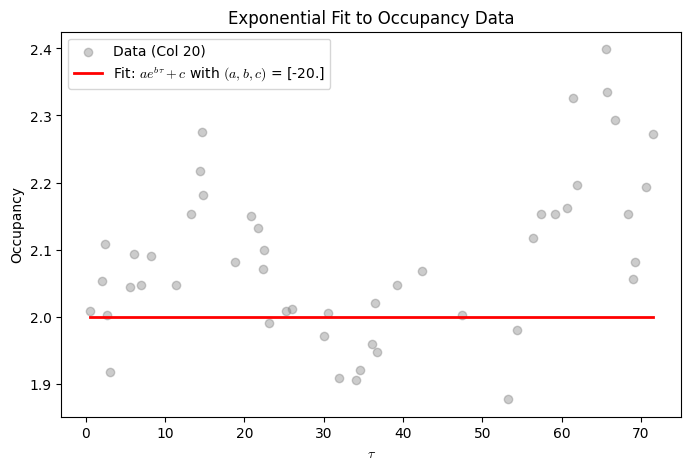

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def exponential(a, c):
    def f(x, b):
        return a * np.exp(b * x) + c
    return f

p_opt, p_cov = curve_fit(exponential(a, c), tau_t, meso[:,2, 0], p0=(-20))

x_fit = np.linspace(min(tau_t), max(tau_t), 100)
y_fit = exponential(a, c)(x_fit, *p_opt)

plt.figure(figsize=(8, 5))

plt.scatter(tau_t[:], meso[:,2, 0], color='gray', alpha=0.4, label='Data (Col 20)')

plt.plot(x_fit, y_fit, color='red', linewidth=2, 
         label=fr'Fit: $ae^{{b\tau}} + c$ with $(a, b, c)$ = {p_opt}')

# 3. Formatting
plt.xlabel(r'$\tau$')
plt.ylabel('Occupancy')
plt.title('Exponential Fit to Occupancy Data')

# Snap the frame to the data
plt.axis('tight') 

# Display the legend
plt.legend()

plt.show()

24. sth for kappa = 1
24.8 for kappa = 2
and 
33 or so for kappa = 10 (should be like 30) and 600 entries
let's see what it is for 400

In [21]:
(5 / 3)**3

4.629629629629631

In [22]:
# we should be getting a decay rate of Dc / 2 * (2pi / N)^2 - kappa, where Dc and kappa are the numbers in the simulation for 200 sites it's 1 * 200 * 2

0.1*(2 * np.pi) ** 2 + 1

4.947841760435743

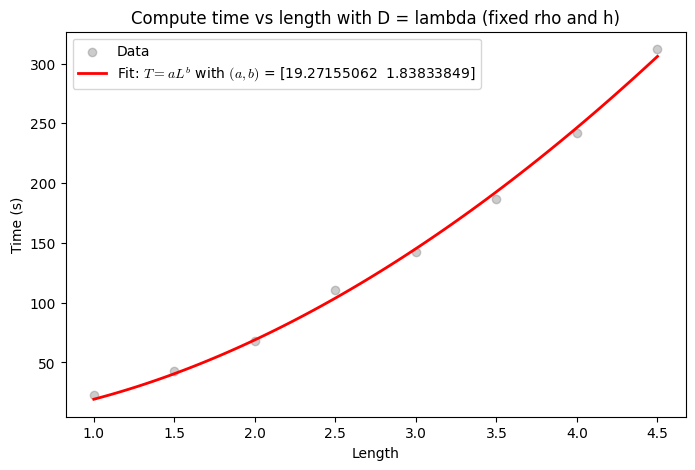

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

Ls = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5]
Ts = [23, 43, 68, 111, 142, 187, 242, 312]

def ln(x, a, b):
    return a * x ** b

p_opt, p_cov = curve_fit(ln, Ls, Ts, p0=(1, 4/3))

x_fit = np.linspace(min(Ls), max(Ls), 100)
y_fit = ln(x_fit, *p_opt)

plt.figure(figsize=(8, 5))

plt.scatter(Ls[:], Ts[:], color='gray', alpha=0.4, label='Data')

plt.plot(x_fit, y_fit, color='red', linewidth=2, 
         label=fr'Fit: $T=aL^b$ with $(a, b)$ = {p_opt}')

# 3. Formatting
plt.xlabel('Length')
plt.ylabel('Time (s)')
plt.title('Compute time vs length with D = lambda (fixed rho and h)')

# Snap the frame to the data
plt.axis('tight') 

# Display the legend
plt.legend()

plt.show()

In [24]:
[0]*4

[0, 0, 0, 0]

In [25]:
np.log(3000)

np.float64(8.006367567650246)

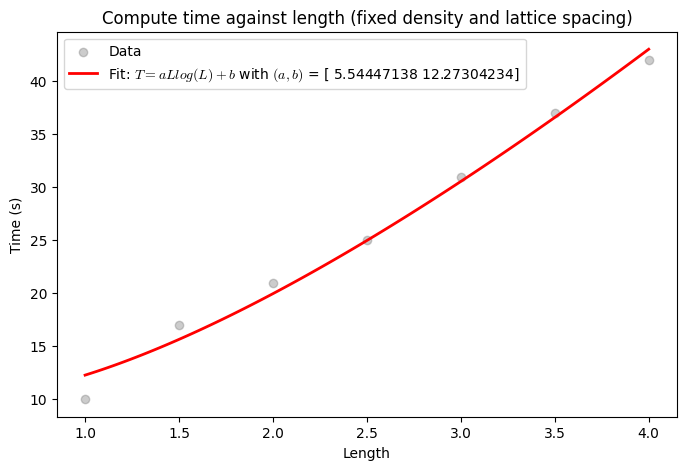

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

Ls = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
Ts = [10, 17, 21, 25, 31, 37, 42]

def ln(x, a, b):
    return a * x * np.log(x) + b

p_opt, p_cov = curve_fit(ln, Ls, Ts, p0=(1, 4/3))

x_fit = np.linspace(min(Ls), max(Ls), 100)
y_fit = ln(x_fit, *p_opt)

plt.figure(figsize=(8, 5))

plt.scatter(Ls[:], Ts[:], color='gray', alpha=0.4, label='Data')

plt.plot(x_fit, y_fit, color='red', linewidth=2, 
         label=fr'Fit: $T = aLlog(L)+ b$ with $(a, b)$ = {p_opt}')

# 3. Formatting
plt.xlabel('Length')
plt.ylabel('Time (s)')
plt.title('Compute time against length (fixed density and lattice spacing)')

# Snap the frame to the data
plt.axis('tight') 

# Display the legend
plt.legend()

plt.show()